In [72]:
import pandas as pd 
import matplotlib.pyplot as plt 

df = pd.read_csv('conversion_predictors_of_clinically_isolated_syndrome_to_multiple_sclerosis.csv')
df.head(5)

,Unnamed: 0,Gender,Age,Schooling,Breastfeeding,Varicella,Initial_Symptom,Mono_or_Polysymptomatic,Oligoclonal_Bands,LLSSEP,ULSSEP,VEP,BAEP,Periventricular_MRI,Cortical_MRI,Infratentorial_MRI,Spinal_Cord_MRI,Initial_EDSS,Final_EDSS,group
0,0,1,34,20.0,1,1,2.0,1,0,1,1,0,0,0,1,0,1,1.0,1.0,1
1,1,1,61,25.0,3,2,10.0,2,1,1,0,1,0,0,0,0,1,2.0,2.0,1
2,2,1,22,20.0,3,1,3.0,1,1,0,0,0,0,0,1,0,0,1.0,1.0,1
3,3,2,41,15.0,1,1,7.0,2,1,0,1,1,0,1,1,0,0,1.0,1.0,1
4,4,2,34,20.0,2,1,6.0,2,0,1,0,0,0,1,0,0,0,1.0,1.0,1


In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 273 entries, 0 to 272
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               273 non-null    int64  
 1   Gender                   273 non-null    int64  
 2   Age                      273 non-null    int64  
 3   Schooling                272 non-null    float64
 4   Breastfeeding            273 non-null    int64  
 5   Varicella                273 non-null    int64  
 6   Initial_Symptom          272 non-null    float64
 7   Mono_or_Polysymptomatic  273 non-null    int64  
 8   Oligoclonal_Bands        273 non-null    int64  
 9   LLSSEP                   273 non-null    int64  
 10  ULSSEP                   273 non-null    int64  
 11  VEP                      273 non-null    int64  
 12  BAEP                     273 non-null    int64  
 13  Periventricular_MRI      273 non-null    int64  
 14  Cortical_MRI             273 non-null

In [73]:
df.columns

Index(['Unnamed: 0', 'Gender', 'Age', 'Schooling', 'Breastfeeding',
       'Varicella', 'Initial_Symptom', 'Mono_or_Polysymptomatic',
       'Oligoclonal_Bands', 'LLSSEP', 'ULSSEP', 'VEP', 'BAEP',
       'Periventricular_MRI', 'Cortical_MRI', 'Infratentorial_MRI',
       'Spinal_Cord_MRI', 'Initial_EDSS', 'Final_EDSS', 'group'],
      dtype='str')

In [69]:
gender = {1:'Male', 2: 'Female'} # Changing numbers into words
breastfeeding = {1: 'Yes', 2:'No', 3:'Unknown'}
varicella = {1 : 'Positive', 2: 'Negative', 3: 'Unknown'}
group = {1: 'CDMS' , 2: 'Non-CDMS' }
Mono_or_Polysymptomatic = {1: 'Monosymptomatic', 2: 'Polysymptomatic', 3: 'Unknown'}
general = {0: 'Negative', 1: 'Positive', 2: 'Unknown'}

df['Gender'] = df['Gender'].map(gender)
df['Breastfeeding'] = df['Breastfeeding'].map(breastfeeding)
df['Varicella'] = df['Varicella'].map(varicella)
df['Mono_or_Polysymptomatic'] = df['Mono_or_Polysymptomatic'].map(Mono_or_Polysymptomatic)
df['group'] = df['group'].map(group)
df['Oligoclonal_Bands'] = df['Oligoclonal_Bands'].map(general)
df['LLSSEP'] = df['LLSSEP'].map(general)
df['ULSSEP'] = df['ULSSEP'].map(general)
df['VEP'] = df['VEP'].map(general)
df['BAEP'] = df['BAEP'].map(general)
df['Periventricular_MRI'] = df['Periventricular_MRI'].map(general)
df['Cortical_MRI'] = df['Cortical_MRI'].map(general)
df['Infratentorial_MRI'] = df['Infratentorial_MRI'].map(general)
df['Spinal_Cord_MRI'] = df['Spinal_Cord_MRI'].map(general)
df['Initial_EDSS'] = df['Initial_EDSS'].astype('Int64').map(general)
df['Final_EDSS'] = df['Final_EDSS'].astype('Int64').map(general)

In [70]:
df = df.rename(columns = {'Schooling': 'Years_in_School', 'group': 'Group', 'Unnamed: 0': 'ID'}) # Renaming some columns
df

,ID,Gender,Age,Years_in_School,Breastfeeding,Varicella,Initial_Symptom,Mono_or_Polysymptomatic,Oligoclonal_Bands,LLSSEP,ULSSEP,VEP,BAEP,Periventricular_MRI,Cortical_MRI,Infratentorial_MRI,Spinal_Cord_MRI,Initial_EDSS,Final_EDSS,Group
0,0,Male,34,20.0,Yes,Positive,2.0,Monosymptomatic,Negative,Positive,Positive,Negative,Negative,Negative,Positive,Negative,Positive,Positive,Positive,CDMS
1,1,Male,61,25.0,Unknown,Negative,10.0,Polysymptomatic,Positive,Positive,Negative,Positive,Negative,Negative,Negative,Negative,Positive,Unknown,Unknown,CDMS
2,2,Male,22,20.0,Unknown,Positive,3.0,Monosymptomatic,Positive,Negative,Negative,Negative,Negative,Negative,Positive,Negative,Negative,Positive,Positive,CDMS
3,3,Female,41,15.0,Yes,Positive,7.0,Polysymptomatic,Positive,Negative,Positive,Positive,Negative,Positive,Positive,Negative,Negative,Positive,Positive,CDMS
4,4,Female,34,20.0,No,Positive,6.0,Polysymptomatic,Negative,Positive,Negative,Negative,Negative,Positive,Negative,Negative,Negative,Positive,Positive,CDMS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268,268,Female,31,8.0,Unknown,Positive,9.0,Polysymptomatic,Negative,Negative,Negative,Negative,Negative,Negative,Negative,Negative,Negative,NaN,NaN,Non-CDMS
269,269,Male,21,15.0,Unknown,Unknown,5.0,Polysymptomatic,Positive,Negative,Negative,Negative,Negative,Negative,Negative,Negative,Positive,NaN,NaN,Non-CDMS
270,270,Female,19,12.0,Unknown,Unknown,13.0,Polysymptomatic,Negative,Positive,Positive,Positive,Negative,Negative,Negative,Negative,Positive,NaN,NaN,Non-CDMS
271,271,Female,32,15.0,Unknown,Unknown,15.0,Polysymptomatic,Positive,Positive,Positive,Positive,Negative,Positive,Positive,Positive,Negative,NaN,NaN,Non-CDMS


<BarContainer object of 2 artists>

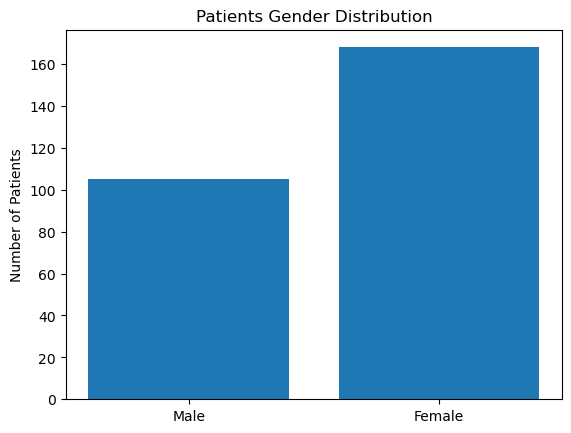

In [61]:
# Exploratoring the dataset
x = ['Male', 'Female']
y = (df['Gender'] == 'Male').sum(), (df['Gender'] == 'Female').sum()
plt.title('Patients Gender Distribution')
plt.ylabel('Number of Patients')
plt.bar(x, y)


Text(0, 0.5, 'Number of Patients')

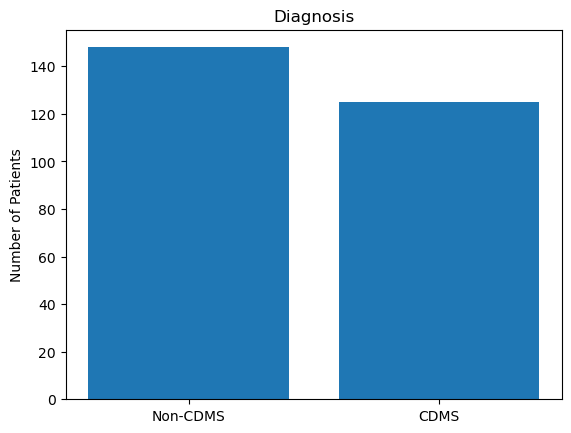

In [58]:
Group = df['Group'].value_counts()
plt.title('Diagnosis')
plt.bar(Group.index, Group)
plt.ylabel('Number of Patients')

Text(0, 0.5, 'Number of Patients')

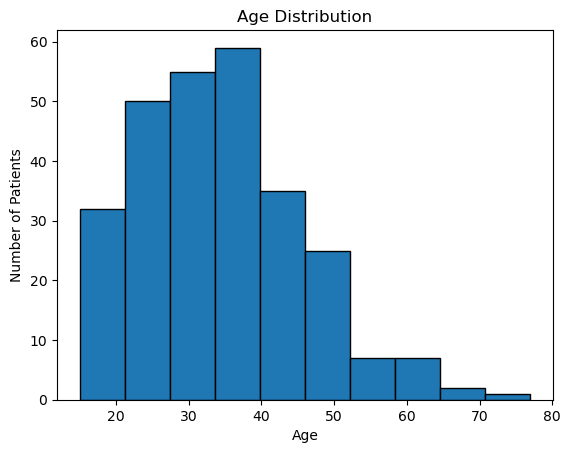

In [49]:
plt.hist(df['Age'], bins = 10, edgecolor = 'black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Patients')

Text(0, 0.5, 'Number of Patients')

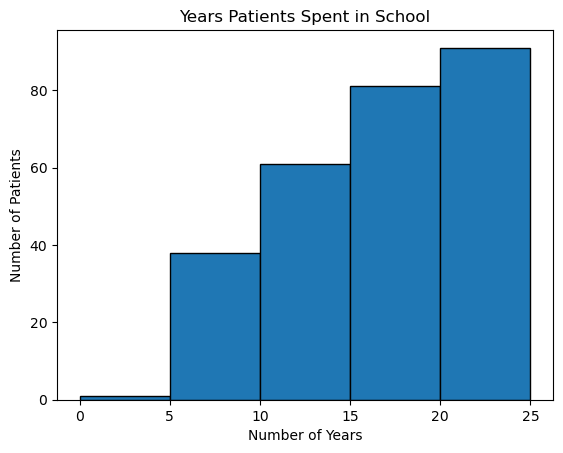

In [47]:

plt.hist(df['Years_in_School'], bins = 5, edgecolor = 'black')
plt.title('Years Patients Spent in School')
plt.xlabel('Number of Years')
plt.ylabel('Number of Patients')

Text(0, 0.5, 'Number of patients')

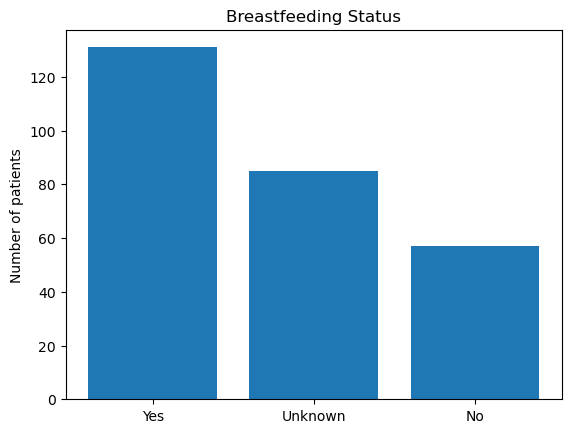

In [53]:
Breastfeeding = df['Breastfeeding'].value_counts()
plt.title('Breastfeeding Status')
plt.bar(Breastfeeding.index, Breastfeeding)
plt.ylabel('Number of patients')

Text(0, 0.5, 'Number of Patients')

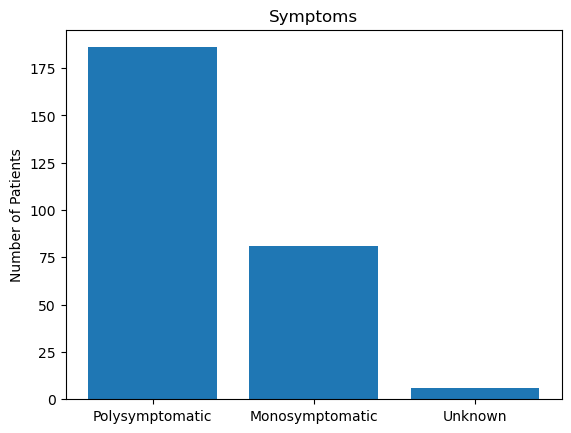

In [55]:
Mono_or_Polysymptomatic = df['Mono_or_Polysymptomatic'].value_counts()
plt.title('Symptoms')
plt.bar(Mono_or_Polysymptomatic.index, Mono_or_Polysymptomatic)
plt.ylabel('Number of Patients')

In [71]:
# Saving the resulted dataframe in CSV format
df.to_csv('ms_data_cleaned.csv', index=False)

In [75]:
df = pd.read_csv('conversion_predictors_of_clinically_isolated_syndrome_to_multiple_sclerosis.csv')
df = df.rename(columns = {'Unnamed: 0': 'ID'})
df

,ID,Gender,Age,Schooling,Breastfeeding,Varicella,Initial_Symptom,Mono_or_Polysymptomatic,Oligoclonal_Bands,LLSSEP,ULSSEP,VEP,BAEP,Periventricular_MRI,Cortical_MRI,Infratentorial_MRI,Spinal_Cord_MRI,Initial_EDSS,Final_EDSS,group
0,0,1,34,20.0,1,1,2.0,1,0,1,1,0,0,0,1,0,1,1.0,1.0,1
1,1,1,61,25.0,3,2,10.0,2,1,1,0,1,0,0,0,0,1,2.0,2.0,1
2,2,1,22,20.0,3,1,3.0,1,1,0,0,0,0,0,1,0,0,1.0,1.0,1
3,3,2,41,15.0,1,1,7.0,2,1,0,1,1,0,1,1,0,0,1.0,1.0,1
4,4,2,34,20.0,2,1,6.0,2,0,1,0,0,0,1,0,0,0,1.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268,268,2,31,8.0,3,1,9.0,2,0,0,0,0,0,0,0,0,0,NaN,NaN,2
269,269,1,21,15.0,3,3,5.0,2,1,0,0,0,0,0,0,0,1,NaN,NaN,2
270,270,2,19,12.0,3,3,13.0,2,0,1,1,1,0,0,0,0,1,NaN,NaN,2
271,271,2,32,15.0,3,3,15.0,2,1,1,1,1,0,1,1,1,0,NaN,NaN,2


In [76]:
df.to_csv('conversion_predictors_of_clinically_isolated_syndrome_to_multiple_sclerosis.csv')